
# Guia practica: Modelos lineales VS procesos para prediccion de caudal

## Problema

Se comparan modelos estadisticos y un modelo basado en procesos para predecir el caudal en dos cuencas colombianas:

- `APARTADO [12017060]`
- `PUENTE CARRETERA - AUT [21137030]`

En ambos casos se usa:

- `75%` inicial de la serie para entrenamiento o calibracion,
- `25%` final para evaluacion,
- precipitacion CHIRPS,
- caudal diario IDEAM,
- temperatura mensual NASA POWER para estimar PET con Thornthwaite.

## Modelos comparados

1. `ARX(3,1)` como modelo lineal con memoria hidrologica y precipitacion exogena.
2. una familia `ARIMAX` no estacional.
3. una familia `SARIMAX` estacional mensual.
4. un modelo fisico parsimonioso de balance de agua con reservorio lineal.

## Hipotesis metodologicas

- La escala mensual es mas robusta que la diaria porque las series de caudal presentan faltantes.
- El caudal mensual puede expresarse como profundidad equivalente (`mm/mes`) para compararlo con `P` y `ET`.
- En el largo plazo, el cambio neto de almacenamiento tiende a ser pequeno respecto a entradas y salidas del sistema, por lo que `dS/dt` puede aproximarse a cero en sentido climatologico.
- Thornthwaite es una aproximacion simple de PET util para un ejercicio docente, aunque no representa toda la complejidad atmosferica.


In [1]:

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hydro_modeling_utils as h

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.3f}'.format

ROOT = Path.cwd()
DATA_ROOT = ROOT / 'DataBasin-20260217T231911Z-1-001' / 'DataBasin'

BASINS = {
    'APARTADO': {
        'title': 'APARTADO [12017060]',
        'dir': 'APARTADO [12017060]',
        'flow_csv': 'Caudal medio diario - APARTADO [12017060].csv',
        'p_csv': '12017060 CHIRPS P1d 1981-2022.pcsv',
        'power_json': 'apartado_nasa_power_t2m_1984_2012.json',
        'lat': 7.866,
        'lon': -76.564,
        'start': '1984-01-01',
        'end': '2012-12-01',
        'area_m2': 87185953.0,
    },
    'PUENTE': {
        'title': 'PUENTE CARRETERA - AUT [21137030]',
        'dir': 'PUENTE CARRETERA - AUT [21137030]',
        'flow_csv': 'Caudal medio diario - PUENTE CARRETERA - AUT [21137030].csv',
        'p_csv': '21137030 CHIRPS P1d 1981-2022.pcsv',
        'power_json': 'puente_nasa_power_t2m_1981_2022.json',
        'lat': 3.180866,
        'lon': -75.465966,
        'start': '1981-01-01',
        'end': '2022-01-01',
        'area_m2': 658750174.912003,
    },
}



## Metodologia general

Para cada cuenca se sigue el mismo procedimiento:

1. lectura de precipitacion diaria y caudal diario,
2. inspeccion visual de las series crudas,
3. agregacion mensual y conversion del caudal a `mm/mes`,
4. estimacion de PET mediante Thornthwaite a partir de temperatura NASA POWER,
5. division cronologica 75/25,
6. ajuste del modelo `ARX(3,1)`,
7. evaluacion de candidatos `ARIMAX` y `SARIMAX`,
8. calibracion del modelo fisico,
9. comparacion final de desempeno.


## Cuenca: APARTADO [12017060]

In [2]:

apartado_cfg = BASINS['APARTADO']
apartado_input_dir = DATA_ROOT / apartado_cfg['dir']
apartado_precip_daily = h.read_precipitation(apartado_input_dir / apartado_cfg['p_csv'])
apartado_flow_daily = h.read_flow(apartado_input_dir / apartado_cfg['flow_csv'])
apartado_temp_monthly = h.read_power_temperature(ROOT / apartado_cfg['power_json'])

print('Precipitacion diaria:', apartado_precip_daily['date'].min().date(), 'a', apartado_precip_daily['date'].max().date(), f"(n={len(apartado_precip_daily)})")
print('Caudal diario      :', apartado_flow_daily['date'].min().date(), 'a', apartado_flow_daily['date'].max().date(), f"(n={len(apartado_flow_daily)})")
print('Temperatura mensual:', apartado_temp_monthly['date'].min().date(), 'a', apartado_temp_monthly['date'].max().date(), f"(n={len(apartado_temp_monthly)})")
print(f"Area de cuenca: {apartado_cfg['area_m2'] / 1e6:.3f} km2")


Precipitacion diaria: 1981-01-01 a 2022-12-31 (n=15340)
Caudal diario      : 1984-01-02 a 2012-12-12 (n=10010)
Temperatura mensual: 1984-01-01 a 2012-12-01 (n=348)
Area de cuenca: 87.186 km2


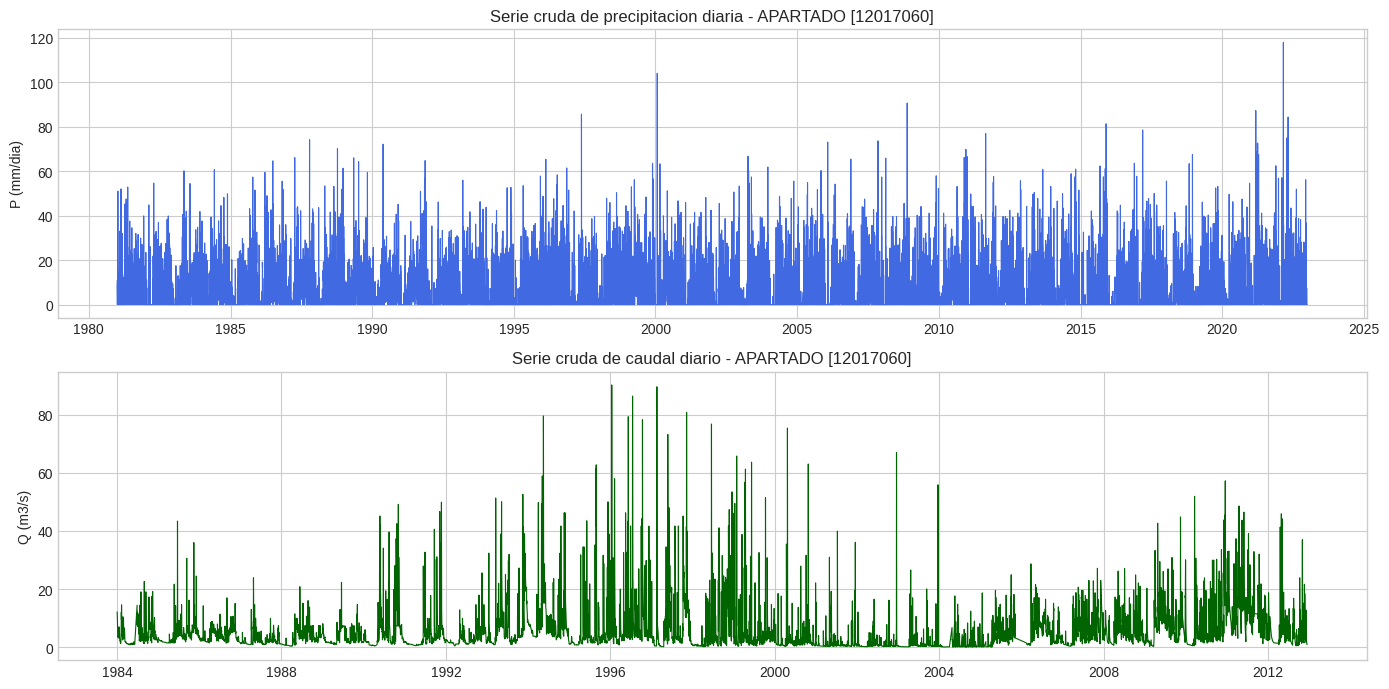

In [3]:

fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
axs[0].plot(apartado_precip_daily['date'], apartado_precip_daily['p_mm'], color='royalblue', linewidth=0.8)
axs[0].set_title('Serie cruda de precipitacion diaria - APARTADO [12017060]')
axs[0].set_ylabel('P (mm/dia)')

axs[1].plot(apartado_flow_daily['date'], apartado_flow_daily['q_m3s'], color='darkgreen', linewidth=0.8)
axs[1].set_title('Serie cruda de caudal diario - APARTADO [12017060]')
axs[1].set_ylabel('Q (m3/s)')
plt.tight_layout()
plt.show()


In [4]:

apartado_df = h.prepare_monthly_dataframe(
    apartado_precip_daily,
    apartado_flow_daily,
    apartado_cfg['area_m2'],
    apartado_temp_monthly,
    apartado_cfg['lat'],
    apartado_cfg['start'],
    apartado_cfg['end'],
)

print('Rango mensual:', apartado_df.index.min().date(), 'a', apartado_df.index.max().date())
print('Meses totales:', len(apartado_df))
print('Meses con caudal valido:', int(apartado_df['q_mm_month'].notna().sum()))
print('Meses invalidos por cobertura:', int(apartado_df['q_mm_month'].isna().sum()))

summary_apartado = pd.DataFrame({
    'variable': ['Precipitacion mensual', 'Temperatura mensual', 'PET Thornthwaite', 'Caudal mensual observado'],
    'media': [apartado_df['p_mm'].mean(), apartado_df['t2m_c'].mean(), apartado_df['pet_mm'].mean(), apartado_df['q_mm_month'].mean()],
    'desv_std': [apartado_df['p_mm'].std(), apartado_df['t2m_c'].std(), apartado_df['pet_mm'].std(), apartado_df['q_mm_month'].std()],
    'min': [apartado_df['p_mm'].min(), apartado_df['t2m_c'].min(), apartado_df['pet_mm'].min(), apartado_df['q_mm_month'].min()],
    'max': [apartado_df['p_mm'].max(), apartado_df['t2m_c'].max(), apartado_df['pet_mm'].max(), apartado_df['q_mm_month'].max()],
})
summary_apartado


Rango mensual: 1984-01-01 a 2012-12-01
Meses totales: 348
Meses con caudal valido: 308
Meses invalidos por cobertura: 40


,variable,media,desv_std,min,max
0,Precipitacion mensual,237.355,118.220,5.430,572.740
1,Temperatura mensual,25.381,0.592,24.090,27.660
2,PET Thornthwaite,118.829,10.741,93.617,160.579
3,Caudal mensual observado,158.903,131.734,4.241,683.284


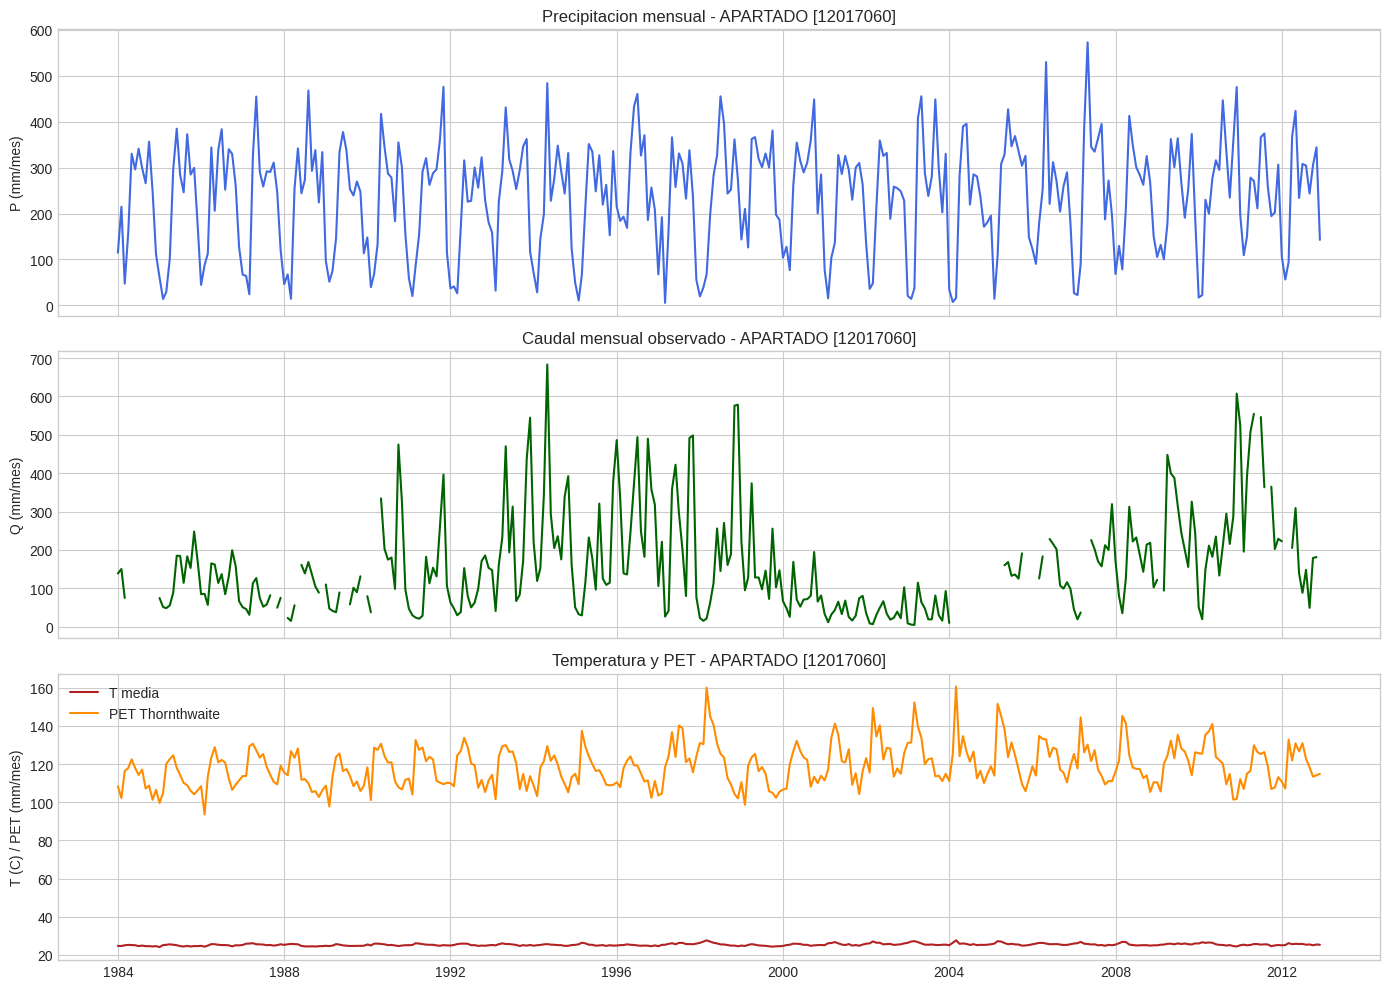

Nota metodologica sobre PET y balance de agua
- La PET se estima con Thornthwaite a partir de temperatura media mensual y fotoperiodo.
- En el modelo fisico, la lluvia entra como forzamiento, la PET aproxima la demanda atmosferica y el parametro k controla la recesion del almacenamiento.
- A largo plazo, dS/dt se aproxima a cero porque el almacenamiento medio no crece ni decrece indefinidamente cuando se analizan periodos amplios.


In [5]:

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axs[0].plot(apartado_df.index, apartado_df['p_mm'], color='royalblue')
axs[0].set_ylabel('P (mm/mes)')
axs[0].set_title('Precipitacion mensual - APARTADO [12017060]')

axs[1].plot(apartado_df.index, apartado_df['q_mm_month'], color='darkgreen')
axs[1].set_ylabel('Q (mm/mes)')
axs[1].set_title('Caudal mensual observado - APARTADO [12017060]')

axs[2].plot(apartado_df.index, apartado_df['t2m_c'], color='firebrick', label='T media')
axs[2].plot(apartado_df.index, apartado_df['pet_mm'], color='darkorange', label='PET Thornthwaite')
axs[2].set_ylabel('T (C) / PET (mm/mes)')
axs[2].set_title('Temperatura y PET - APARTADO [12017060]')
axs[2].legend()
plt.tight_layout()
plt.show()

print('Nota metodologica sobre PET y balance de agua')
print('- La PET se estima con Thornthwaite a partir de temperatura media mensual y fotoperiodo.')
print('- En el modelo fisico, la lluvia entra como forzamiento, la PET aproxima la demanda atmosferica y el parametro k controla la recesion del almacenamiento.')
print('- A largo plazo, dS/dt se aproxima a cero porque el almacenamiento medio no crece ni decrece indefinidamente cuando se analizan periodos amplios.')


In [6]:

apartado_train_all, apartado_test_all, apartado_split = h.train_test_split_time(apartado_df, frac_train=0.75)
apartado_train_obs = apartado_train_all.dropna(subset=['q_mm_month']).copy()
apartado_test_obs = apartado_test_all.dropna(subset=['q_mm_month']).copy()

print('Entrenamiento:', apartado_train_all.index.min().date(), 'a', apartado_train_all.index.max().date(), f"({len(apartado_train_all)} meses)")
print('Evaluacion   :', apartado_test_all.index.min().date(), 'a', apartado_test_all.index.max().date(), f"({len(apartado_test_all)} meses)")
print('Meses validos en entrenamiento:', len(apartado_train_obs))
print('Meses validos en evaluacion   :', len(apartado_test_obs))


Entrenamiento: 1984-01-01 a 2005-09-01 (261 meses)
Evaluacion   : 2005-10-01 a 2012-12-01 (87 meses)
Meses validos en entrenamiento: 234
Meses validos en evaluacion   : 74


### Modelos estadisticos en APARTADO [12017060]

In [7]:

apartado_arx_design = h.build_arx_design(apartado_df)
apartado_arx_model = h.fit_arx(apartado_arx_design.iloc[:apartado_split])
apartado_df['q_arx_mm'] = h.predict_arx_recursive(apartado_arx_design, apartado_split, apartado_arx_model)
apartado_train_fitted = h.predict_arx_in_sample(apartado_arx_design.iloc[:apartado_split], apartado_arx_model)
apartado_df.loc[apartado_train_fitted.index, 'q_arx_train_mm'] = apartado_train_fitted['qhat_mm']
apartado_df['q_arx_m3s'] = apartado_df['q_arx_mm'] * apartado_cfg['area_m2'] / (1000.0 * 86400.0 * apartado_df['days_in_month'].astype(float))

apartado_arx_train_metrics = h.compute_metrics(apartado_df.loc[apartado_train_fitted.index, 'q_mm_month'], apartado_df.loc[apartado_train_fitted.index, 'q_arx_train_mm'])
apartado_arx_test_metrics = h.compute_metrics(apartado_test_obs['q_mm_month'], apartado_df.loc[apartado_test_obs.index, 'q_arx_mm'])

apartado_sarimax_rows, apartado_best_by_family = h.fit_sarimax_candidates(apartado_train_all, apartado_test_all)
apartado_best_arimax = apartado_best_by_family['ARIMAX']
apartado_best_sarimax = apartado_best_by_family['SARIMAX']

apartado_df['q_arimax_mm'] = pd.concat([apartado_best_arimax['train_pred'], apartado_best_arimax['test_pred']]).reindex(apartado_df.index)
apartado_df['q_sarimax_mm'] = pd.concat([apartado_best_sarimax['train_pred'], apartado_best_sarimax['test_pred']]).reindex(apartado_df.index)
apartado_df['q_arimax_m3s'] = apartado_df['q_arimax_mm'] * apartado_cfg['area_m2'] / (1000.0 * 86400.0 * apartado_df['days_in_month'].astype(float))
apartado_df['q_sarimax_m3s'] = apartado_df['q_sarimax_mm'] * apartado_cfg['area_m2'] / (1000.0 * 86400.0 * apartado_df['days_in_month'].astype(float))

print('Coeficientes del ARX(3,1):')
for name, value in zip(['intercepto'] + apartado_arx_model['columns'], apartado_arx_model['beta']):
    print(f'- {name}: {value:.4f}')

print('\nMetricas ARX (mm/mes)')
display(pd.DataFrame([apartado_arx_train_metrics, apartado_arx_test_metrics], index=['train', 'test']))

apartado_candidate_table = pd.DataFrame([
    {
        'modelo': row['name'],
        'familia': row['family'],
        'aic': row.get('aic', np.nan),
        'rmse_test': np.nan if row.get('test_metrics') is None else row['test_metrics']['rmse'],
        'nse_test': np.nan if row.get('test_metrics') is None else row['test_metrics']['nse'],
        'corr_test': np.nan if row.get('test_metrics') is None else row['test_metrics']['corr'],
    }
    for row in apartado_sarimax_rows
]).sort_values(['familia', 'rmse_test'])

print('Mejor ARIMAX:', apartado_best_arimax['name'])
print('Mejor SARIMAX:', apartado_best_sarimax['name'])
display(apartado_candidate_table)


Coeficientes del ARX(3,1):
- intercepto: -130.0283
- q_lag1: 0.5352
- q_lag2: -0.1188
- q_lag3: 0.1956
- p_mm: 0.7843
- sin_month: 45.7229
- cos_month: 50.1225

Metricas ARX (mm/mes)


,n,rmse,mae,bias,r2,nse,corr
train,200,87.349,60.081,1.328,0.569,0.569,0.755
test,74,114.617,75.490,-52.407,0.205,0.205,0.610


Mejor ARIMAX: ARIMAX(2,0,1)
Mejor SARIMAX: SARIMAX(1,0,0)x(1,0,0,12)


,modelo,familia,aic,rmse_test,nse_test,corr_test
2,"ARIMAX(2,0,1)",ARIMAX,"2,754.613",134.541,-0.095,0.478
0,"ARIMAX(1,0,0)",ARIMAX,"2,763.697",135.286,-0.107,0.479
1,"ARIMAX(1,0,1)",ARIMAX,"2,753.325",135.366,-0.108,0.478
3,"SARIMAX(1,0,0)x(1,0,0,12)",SARIMAX,"2,691.887",133.965,-0.086,0.483
4,"SARIMAX(1,0,0)x(0,1,1,12)",SARIMAX,"2,572.998",152.070,-0.399,0.440
5,"SARIMAX(1,0,1)x(0,1,1,12)",SARIMAX,"2,562.754",164.773,-0.642,0.429
6,"SARIMAX(2,0,1)x(0,1,1,12)",SARIMAX,"2,548.201",185.895,-1.090,0.406


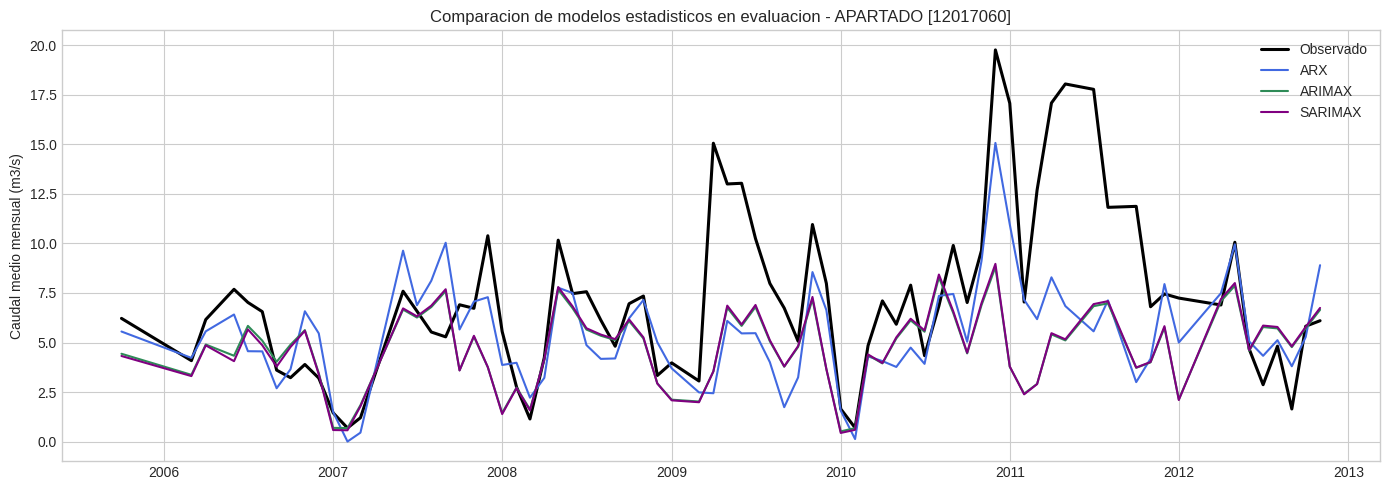

In [8]:

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(apartado_test_obs.index, apartado_test_obs['q_mean_m3s_from_mm'], color='black', linewidth=2.2, label='Observado')
ax.plot(apartado_test_obs.index, apartado_df.loc[apartado_test_obs.index, 'q_arx_m3s'], color='royalblue', linewidth=1.5, label='ARX')
ax.plot(apartado_test_obs.index, apartado_df.loc[apartado_test_obs.index, 'q_arimax_m3s'], color='seagreen', linewidth=1.5, label='ARIMAX')
ax.plot(apartado_test_obs.index, apartado_df.loc[apartado_test_obs.index, 'q_sarimax_m3s'], color='purple', linewidth=1.5, label='SARIMAX')
ax.set_title('Comparacion de modelos estadisticos en evaluacion - APARTADO [12017060]')
ax.set_ylabel('Caudal medio mensual (m3/s)')
ax.legend()
plt.tight_layout()
plt.show()


### Modelo fisico en APARTADO [12017060]

Mejor k calibrado: 0.500
Metricas del modelo fisico (test)


,n,rmse,mae,bias,r2,nse,corr
test,74,144.226,100.980,-82.673,-0.258,-0.258,0.418


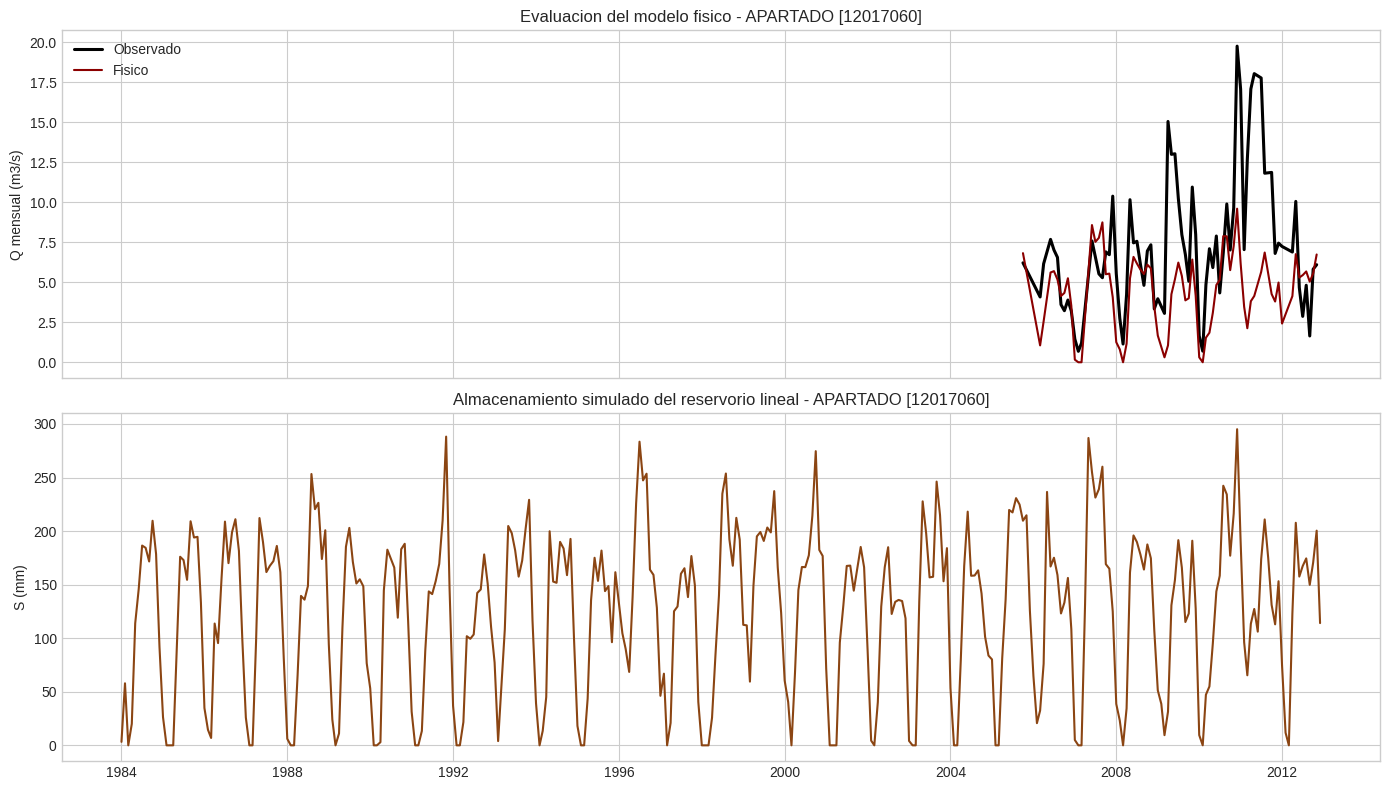

In [9]:

apartado_wb_best = h.calibrate_water_balance(apartado_df, apartado_split)
apartado_wb_sim = h.run_water_balance(apartado_df[['p_mm', 'pet_mm']], apartado_wb_best['k'])
apartado_df['q_phys_mm'] = apartado_wb_sim['qsim_mm']
apartado_df['storage_mm'] = apartado_wb_sim['storage_mm']
apartado_df['q_phys_m3s'] = apartado_df['q_phys_mm'] * apartado_cfg['area_m2'] / (1000.0 * 86400.0 * apartado_df['days_in_month'].astype(float))
apartado_phys_test_metrics = h.compute_metrics(apartado_test_obs['q_mm_month'], apartado_df.loc[apartado_test_obs.index, 'q_phys_mm'])

print(f"Mejor k calibrado: {apartado_wb_best['k']:.3f}")
print('Metricas del modelo fisico (test)')
display(pd.DataFrame([apartado_phys_test_metrics], index=['test']))

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axs[0].plot(apartado_test_obs.index, apartado_test_obs['q_mean_m3s_from_mm'], color='black', linewidth=2.2, label='Observado')
axs[0].plot(apartado_test_obs.index, apartado_df.loc[apartado_test_obs.index, 'q_phys_m3s'], color='darkred', linewidth=1.5, label='Fisico')
axs[0].set_ylabel('Q mensual (m3/s)')
axs[0].set_title('Evaluacion del modelo fisico - APARTADO [12017060]')
axs[0].legend()
axs[1].plot(apartado_df.index, apartado_df['storage_mm'], color='saddlebrown')
axs[1].set_ylabel('S (mm)')
axs[1].set_title('Almacenamiento simulado del reservorio lineal - APARTADO [12017060]')
plt.tight_layout()
plt.show()


### Comparacion final interna en APARTADO [12017060]

In [10]:

apartado_comparison = pd.DataFrame([
    {'modelo': 'Estadistico ARX(3,1)', **apartado_arx_test_metrics},
    {'modelo': apartado_best_arimax['name'], **apartado_best_arimax['test_metrics']},
    {'modelo': apartado_best_sarimax['name'], **apartado_best_sarimax['test_metrics']},
    {'modelo': 'Fisico balance + reservorio', **apartado_phys_test_metrics},
]).set_index('modelo').sort_values('rmse')

apartado_comparison


,n,rmse,mae,bias,r2,nse,corr
modelo,,,,,,,
"Estadistico ARX(3,1)",74,114.617,75.490,-52.407,0.205,0.205,0.610
"SARIMAX(1,0,0)x(1,0,0,12)",74,133.965,88.679,-72.599,-0.086,-0.086,0.483
"ARIMAX(2,0,1)",74,134.541,88.964,-73.101,-0.095,-0.095,0.478
Fisico balance + reservorio,74,144.226,100.980,-82.673,-0.258,-0.258,0.418


In [11]:

print('Conclusiones de APARTADO [12017060]')
print(f"- El mejor modelo por RMSE es: {apartado_comparison.index[0]}.")
print(f"- ARX(3,1): RMSE = {apartado_comparison.loc['Estadistico ARX(3,1)', 'rmse']:.2f} mm/mes, NSE = {apartado_comparison.loc['Estadistico ARX(3,1)', 'nse']:.3f}.")
print(f"- Mejor ARIMAX: {apartado_best_arimax['name']} | RMSE = {apartado_comparison.loc[apartado_best_arimax['name'], 'rmse']:.2f} mm/mes.")
print(f"- Mejor SARIMAX: {apartado_best_sarimax['name']} | RMSE = {apartado_comparison.loc[apartado_best_sarimax['name'], 'rmse']:.2f} mm/mes.")
print(f"- Fisico: RMSE = {apartado_comparison.loc['Fisico balance + reservorio', 'rmse']:.2f} mm/mes.")


Conclusiones de APARTADO [12017060]
- El mejor modelo por RMSE es: Estadistico ARX(3,1).
- ARX(3,1): RMSE = 114.62 mm/mes, NSE = 0.205.
- Mejor ARIMAX: ARIMAX(2,0,1) | RMSE = 134.54 mm/mes.
- Mejor SARIMAX: SARIMAX(1,0,0)x(1,0,0,12) | RMSE = 133.96 mm/mes.
- Fisico: RMSE = 144.23 mm/mes.


## Cuenca: PUENTE CARRETERA - AUT [21137030]

In [12]:

puente_cfg = BASINS['PUENTE']
puente_input_dir = DATA_ROOT / puente_cfg['dir']
puente_precip_daily = h.read_precipitation(puente_input_dir / puente_cfg['p_csv'])
puente_flow_daily = h.read_flow(puente_input_dir / puente_cfg['flow_csv'])
puente_temp_monthly = h.read_power_temperature(ROOT / puente_cfg['power_json'])

print('Precipitacion diaria:', puente_precip_daily['date'].min().date(), 'a', puente_precip_daily['date'].max().date(), f"(n={len(puente_precip_daily)})")
print('Caudal diario      :', puente_flow_daily['date'].min().date(), 'a', puente_flow_daily['date'].max().date(), f"(n={len(puente_flow_daily)})")
print('Temperatura mensual:', puente_temp_monthly['date'].min().date(), 'a', puente_temp_monthly['date'].max().date(), f"(n={len(puente_temp_monthly)})")
print(f"Area de cuenca: {puente_cfg['area_m2'] / 1e6:.3f} km2")


Precipitacion diaria: 1981-01-01 a 2022-12-31 (n=15340)
Caudal diario      : 1972-02-01 a 2022-01-03 (n=17115)
Temperatura mensual: 1981-01-01 a 2022-12-01 (n=504)
Area de cuenca: 658.750 km2


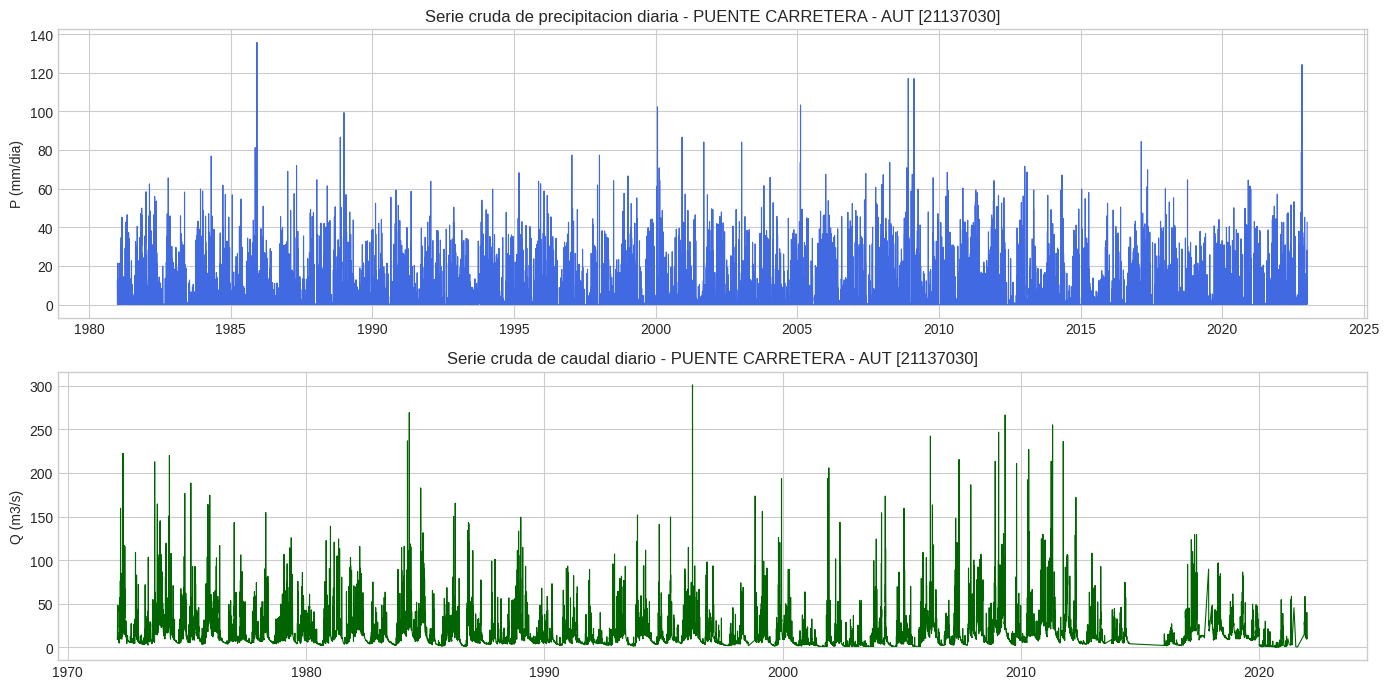

In [13]:

fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
axs[0].plot(puente_precip_daily['date'], puente_precip_daily['p_mm'], color='royalblue', linewidth=0.8)
axs[0].set_title('Serie cruda de precipitacion diaria - PUENTE CARRETERA - AUT [21137030]')
axs[0].set_ylabel('P (mm/dia)')

axs[1].plot(puente_flow_daily['date'], puente_flow_daily['q_m3s'], color='darkgreen', linewidth=0.8)
axs[1].set_title('Serie cruda de caudal diario - PUENTE CARRETERA - AUT [21137030]')
axs[1].set_ylabel('Q (m3/s)')
plt.tight_layout()
plt.show()


In [14]:

puente_df = h.prepare_monthly_dataframe(
    puente_precip_daily,
    puente_flow_daily,
    puente_cfg['area_m2'],
    puente_temp_monthly,
    puente_cfg['lat'],
    puente_cfg['start'],
    puente_cfg['end'],
)

print('Rango mensual:', puente_df.index.min().date(), 'a', puente_df.index.max().date())
print('Meses totales:', len(puente_df))
print('Meses con caudal valido:', int(puente_df['q_mm_month'].notna().sum()))
print('Meses invalidos por cobertura:', int(puente_df['q_mm_month'].isna().sum()))

summary_puente = pd.DataFrame({
    'variable': ['Precipitacion mensual', 'Temperatura mensual', 'PET Thornthwaite', 'Caudal mensual observado'],
    'media': [puente_df['p_mm'].mean(), puente_df['t2m_c'].mean(), puente_df['pet_mm'].mean(), puente_df['q_mm_month'].mean()],
    'desv_std': [puente_df['p_mm'].std(), puente_df['t2m_c'].std(), puente_df['pet_mm'].std(), puente_df['q_mm_month'].std()],
    'min': [puente_df['p_mm'].min(), puente_df['t2m_c'].min(), puente_df['pet_mm'].min(), puente_df['q_mm_month'].min()],
    'max': [puente_df['p_mm'].max(), puente_df['t2m_c'].max(), puente_df['pet_mm'].max(), puente_df['q_mm_month'].max()],
})
summary_puente


Rango mensual: 1981-01-01 a 2022-01-01
Meses totales: 493
Meses con caudal valido: 447
Meses invalidos por cobertura: 46


,variable,media,desv_std,min,max
0,Precipitacion mensual,177.319,103.709,14.410,539.810
1,Temperatura mensual,19.717,0.914,17.370,22.780
2,PET Thornthwaite,73.835,6.112,59.561,92.504
3,Caudal mensual observado,62.567,49.313,3.926,373.185


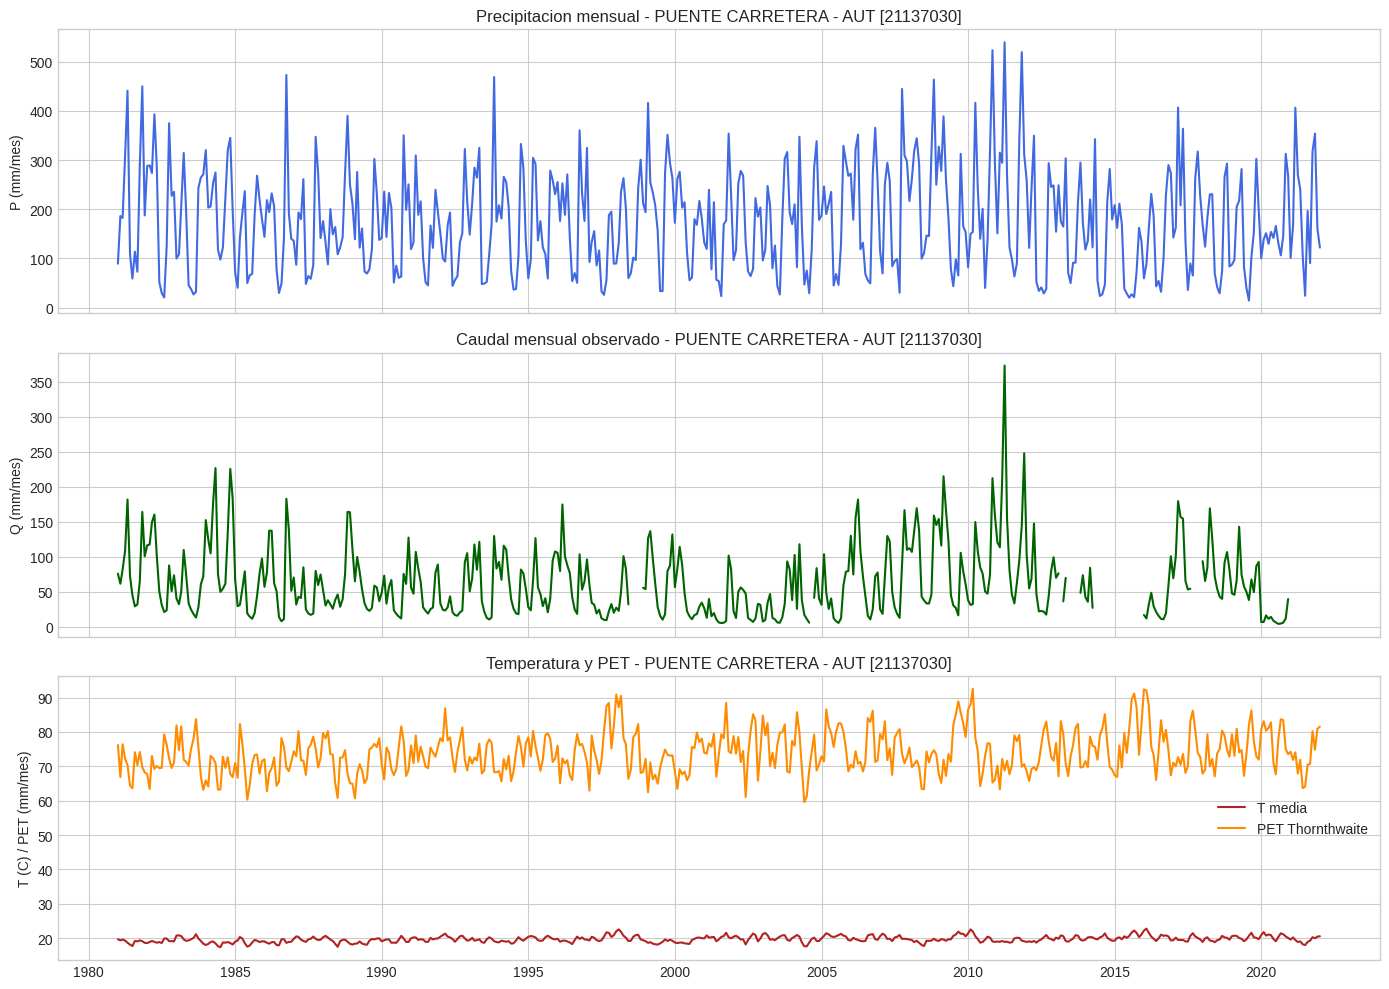

Nota metodologica sobre PET y balance de agua
- La PET se estima con Thornthwaite a partir de temperatura media mensual y fotoperiodo.
- En el modelo fisico, la lluvia entra como forzamiento, la PET aproxima la demanda atmosferica y el parametro k controla la recesion del almacenamiento.
- A largo plazo, dS/dt se aproxima a cero porque el almacenamiento medio no crece ni decrece indefinidamente cuando se analizan periodos amplios.


In [15]:

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axs[0].plot(puente_df.index, puente_df['p_mm'], color='royalblue')
axs[0].set_ylabel('P (mm/mes)')
axs[0].set_title('Precipitacion mensual - PUENTE CARRETERA - AUT [21137030]')

axs[1].plot(puente_df.index, puente_df['q_mm_month'], color='darkgreen')
axs[1].set_ylabel('Q (mm/mes)')
axs[1].set_title('Caudal mensual observado - PUENTE CARRETERA - AUT [21137030]')

axs[2].plot(puente_df.index, puente_df['t2m_c'], color='firebrick', label='T media')
axs[2].plot(puente_df.index, puente_df['pet_mm'], color='darkorange', label='PET Thornthwaite')
axs[2].set_ylabel('T (C) / PET (mm/mes)')
axs[2].set_title('Temperatura y PET - PUENTE CARRETERA - AUT [21137030]')
axs[2].legend()
plt.tight_layout()
plt.show()

print('Nota metodologica sobre PET y balance de agua')
print('- La PET se estima con Thornthwaite a partir de temperatura media mensual y fotoperiodo.')
print('- En el modelo fisico, la lluvia entra como forzamiento, la PET aproxima la demanda atmosferica y el parametro k controla la recesion del almacenamiento.')
print('- A largo plazo, dS/dt se aproxima a cero porque el almacenamiento medio no crece ni decrece indefinidamente cuando se analizan periodos amplios.')


In [16]:

puente_train_all, puente_test_all, puente_split = h.train_test_split_time(puente_df, frac_train=0.75)
puente_train_obs = puente_train_all.dropna(subset=['q_mm_month']).copy()
puente_test_obs = puente_test_all.dropna(subset=['q_mm_month']).copy()

print('Entrenamiento:', puente_train_all.index.min().date(), 'a', puente_train_all.index.max().date(), f"({len(puente_train_all)} meses)")
print('Evaluacion   :', puente_test_all.index.min().date(), 'a', puente_test_all.index.max().date(), f"({len(puente_test_all)} meses)")
print('Meses validos en entrenamiento:', len(puente_train_obs))
print('Meses validos en evaluacion   :', len(puente_test_obs))


Entrenamiento: 1981-01-01 a 2011-09-01 (369 meses)
Evaluacion   : 2011-10-01 a 2022-01-01 (124 meses)
Meses validos en entrenamiento: 363
Meses validos en evaluacion   : 84


### Modelos estadisticos en PUENTE CARRETERA - AUT [21137030]

In [17]:

puente_arx_design = h.build_arx_design(puente_df)
puente_arx_model = h.fit_arx(puente_arx_design.iloc[:puente_split])
puente_df['q_arx_mm'] = h.predict_arx_recursive(puente_arx_design, puente_split, puente_arx_model)
puente_train_fitted = h.predict_arx_in_sample(puente_arx_design.iloc[:puente_split], puente_arx_model)
puente_df.loc[puente_train_fitted.index, 'q_arx_train_mm'] = puente_train_fitted['qhat_mm']
puente_df['q_arx_m3s'] = puente_df['q_arx_mm'] * puente_cfg['area_m2'] / (1000.0 * 86400.0 * puente_df['days_in_month'].astype(float))

puente_arx_train_metrics = h.compute_metrics(puente_df.loc[puente_train_fitted.index, 'q_mm_month'], puente_df.loc[puente_train_fitted.index, 'q_arx_train_mm'])
puente_arx_test_metrics = h.compute_metrics(puente_test_obs['q_mm_month'], puente_df.loc[puente_test_obs.index, 'q_arx_mm'])

puente_sarimax_rows, puente_best_by_family = h.fit_sarimax_candidates(puente_train_all, puente_test_all)
puente_best_arimax = puente_best_by_family['ARIMAX']
puente_best_sarimax = puente_best_by_family['SARIMAX']

puente_df['q_arimax_mm'] = pd.concat([puente_best_arimax['train_pred'], puente_best_arimax['test_pred']]).reindex(puente_df.index)
puente_df['q_sarimax_mm'] = pd.concat([puente_best_sarimax['train_pred'], puente_best_sarimax['test_pred']]).reindex(puente_df.index)
puente_df['q_arimax_m3s'] = puente_df['q_arimax_mm'] * puente_cfg['area_m2'] / (1000.0 * 86400.0 * puente_df['days_in_month'].astype(float))
puente_df['q_sarimax_m3s'] = puente_df['q_sarimax_mm'] * puente_cfg['area_m2'] / (1000.0 * 86400.0 * puente_df['days_in_month'].astype(float))

print('Coeficientes del ARX(3,1):')
for name, value in zip(['intercepto'] + puente_arx_model['columns'], puente_arx_model['beta']):
    print(f'- {name}: {value:.4f}')

print('\nMetricas ARX (mm/mes)')
display(pd.DataFrame([puente_arx_train_metrics, puente_arx_test_metrics], index=['train', 'test']))

puente_candidate_table = pd.DataFrame([
    {
        'modelo': row['name'],
        'familia': row['family'],
        'aic': row.get('aic', np.nan),
        'rmse_test': np.nan if row.get('test_metrics') is None else row['test_metrics']['rmse'],
        'nse_test': np.nan if row.get('test_metrics') is None else row['test_metrics']['nse'],
        'corr_test': np.nan if row.get('test_metrics') is None else row['test_metrics']['corr'],
    }
    for row in puente_sarimax_rows
]).sort_values(['familia', 'rmse_test'])

print('Mejor ARIMAX:', puente_best_arimax['name'])
print('Mejor SARIMAX:', puente_best_sarimax['name'])
display(puente_candidate_table)


Coeficientes del ARX(3,1):
- intercepto: -30.8408
- q_lag1: 0.4350
- q_lag2: -0.0057
- q_lag3: 0.1104
- p_mm: 0.3296
- sin_month: 0.1004
- cos_month: 0.1078

Metricas ARX (mm/mes)


,n,rmse,mae,bias,r2,nse,corr
train,354,22.274,16.493,0.367,0.804,0.804,0.897
test,84,32.601,26.764,-4.031,0.513,0.513,0.736


Mejor ARIMAX: ARIMAX(1,0,0)
Mejor SARIMAX: SARIMAX(1,0,1)x(0,1,1,12)


,modelo,familia,aic,rmse_test,nse_test,corr_test
0,"ARIMAX(1,0,0)",ARIMAX,"3,417.157",36.854,0.377,0.616
2,"ARIMAX(2,0,1)",ARIMAX,"3,408.436",36.875,0.377,0.615
1,"ARIMAX(1,0,1)",ARIMAX,"3,408.079",36.914,0.375,0.614
5,"SARIMAX(1,0,1)x(0,1,1,12)",SARIMAX,"3,154.406",36.055,0.404,0.671
3,"SARIMAX(1,0,0)x(1,0,0,12)",SARIMAX,"3,301.276",36.405,0.393,0.631
6,"SARIMAX(2,0,1)x(0,1,1,12)",SARIMAX,"3,156.612",36.417,0.392,0.666
4,"SARIMAX(1,0,0)x(0,1,1,12)",SARIMAX,"3,162.759",36.517,0.389,0.665


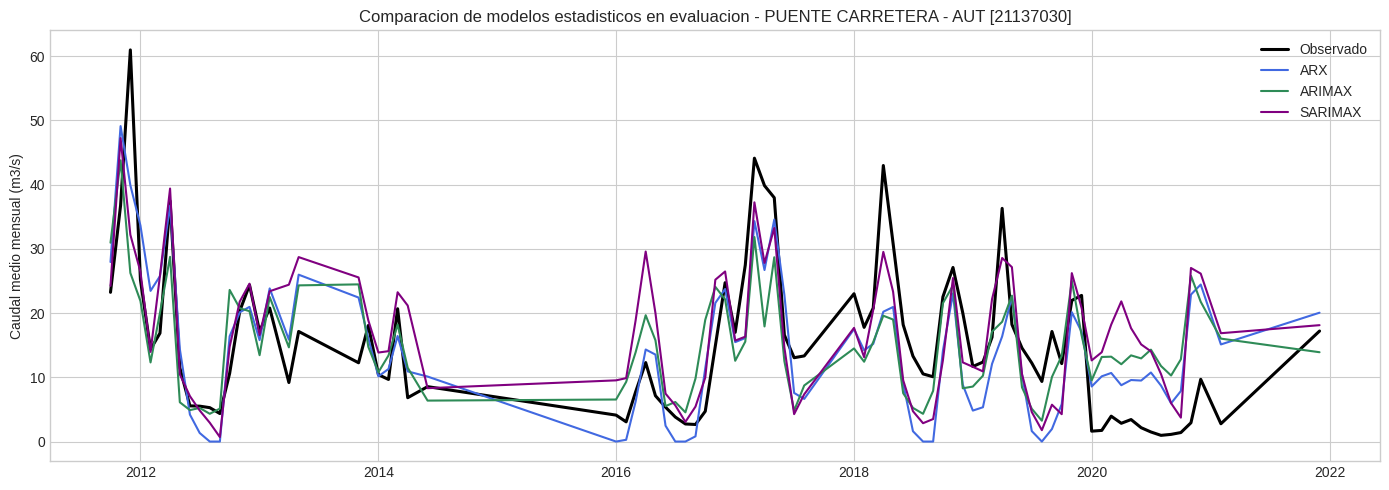

In [18]:

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(puente_test_obs.index, puente_test_obs['q_mean_m3s_from_mm'], color='black', linewidth=2.2, label='Observado')
ax.plot(puente_test_obs.index, puente_df.loc[puente_test_obs.index, 'q_arx_m3s'], color='royalblue', linewidth=1.5, label='ARX')
ax.plot(puente_test_obs.index, puente_df.loc[puente_test_obs.index, 'q_arimax_m3s'], color='seagreen', linewidth=1.5, label='ARIMAX')
ax.plot(puente_test_obs.index, puente_df.loc[puente_test_obs.index, 'q_sarimax_m3s'], color='purple', linewidth=1.5, label='SARIMAX')
ax.set_title('Comparacion de modelos estadisticos en evaluacion - PUENTE CARRETERA - AUT [21137030]')
ax.set_ylabel('Caudal medio mensual (m3/s)')
ax.legend()
plt.tight_layout()
plt.show()


### Modelo fisico en PUENTE CARRETERA - AUT [21137030]

Mejor k calibrado: 0.290
Metricas del modelo fisico (test)


,n,rmse,mae,bias,r2,nse,corr
test,84,49.466,39.523,32.574,-0.122,-0.122,0.712


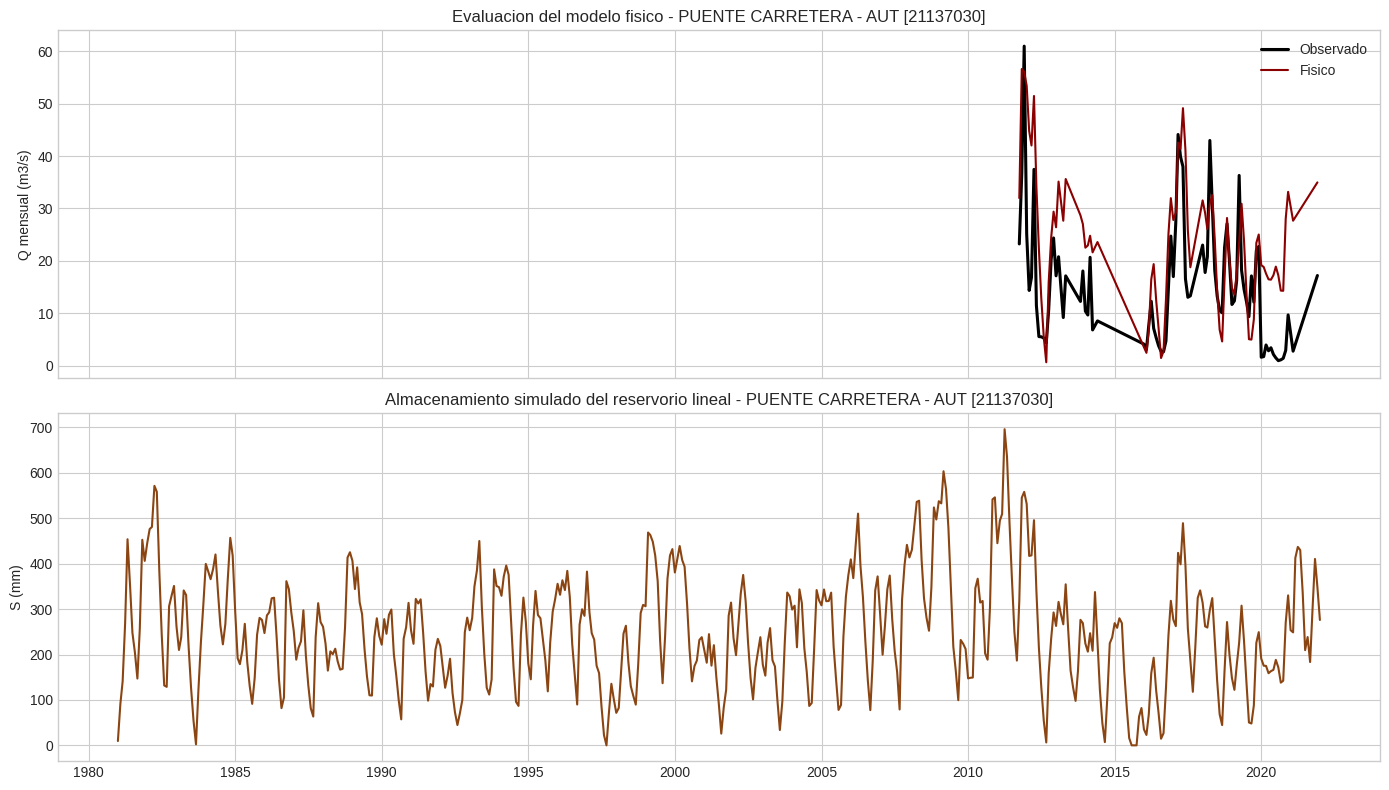

In [19]:

puente_wb_best = h.calibrate_water_balance(puente_df, puente_split)
puente_wb_sim = h.run_water_balance(puente_df[['p_mm', 'pet_mm']], puente_wb_best['k'])
puente_df['q_phys_mm'] = puente_wb_sim['qsim_mm']
puente_df['storage_mm'] = puente_wb_sim['storage_mm']
puente_df['q_phys_m3s'] = puente_df['q_phys_mm'] * puente_cfg['area_m2'] / (1000.0 * 86400.0 * puente_df['days_in_month'].astype(float))
puente_phys_test_metrics = h.compute_metrics(puente_test_obs['q_mm_month'], puente_df.loc[puente_test_obs.index, 'q_phys_mm'])

print(f"Mejor k calibrado: {puente_wb_best['k']:.3f}")
print('Metricas del modelo fisico (test)')
display(pd.DataFrame([puente_phys_test_metrics], index=['test']))

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axs[0].plot(puente_test_obs.index, puente_test_obs['q_mean_m3s_from_mm'], color='black', linewidth=2.2, label='Observado')
axs[0].plot(puente_test_obs.index, puente_df.loc[puente_test_obs.index, 'q_phys_m3s'], color='darkred', linewidth=1.5, label='Fisico')
axs[0].set_ylabel('Q mensual (m3/s)')
axs[0].set_title('Evaluacion del modelo fisico - PUENTE CARRETERA - AUT [21137030]')
axs[0].legend()
axs[1].plot(puente_df.index, puente_df['storage_mm'], color='saddlebrown')
axs[1].set_ylabel('S (mm)')
axs[1].set_title('Almacenamiento simulado del reservorio lineal - PUENTE CARRETERA - AUT [21137030]')
plt.tight_layout()
plt.show()


### Comparacion final interna en PUENTE CARRETERA - AUT [21137030]

In [20]:

puente_comparison = pd.DataFrame([
    {'modelo': 'Estadistico ARX(3,1)', **puente_arx_test_metrics},
    {'modelo': puente_best_arimax['name'], **puente_best_arimax['test_metrics']},
    {'modelo': puente_best_sarimax['name'], **puente_best_sarimax['test_metrics']},
    {'modelo': 'Fisico balance + reservorio', **puente_phys_test_metrics},
]).set_index('modelo').sort_values('rmse')

puente_comparison


,n,rmse,mae,bias,r2,nse,corr
modelo,,,,,,,
"Estadistico ARX(3,1)",84,32.601,26.764,-4.031,0.513,0.513,0.736
"SARIMAX(1,0,1)x(0,1,1,12)",84,36.055,27.805,6.690,0.404,0.404,0.671
"ARIMAX(1,0,0)",84,36.854,28.502,-0.687,0.377,0.377,0.616
Fisico balance + reservorio,84,49.466,39.523,32.574,-0.122,-0.122,0.712


In [21]:

print('Conclusiones de PUENTE CARRETERA - AUT [21137030]')
print(f"- El mejor modelo por RMSE es: {puente_comparison.index[0]}.")
print(f"- ARX(3,1): RMSE = {puente_comparison.loc['Estadistico ARX(3,1)', 'rmse']:.2f} mm/mes, NSE = {puente_comparison.loc['Estadistico ARX(3,1)', 'nse']:.3f}.")
print(f"- Mejor ARIMAX: {puente_best_arimax['name']} | RMSE = {puente_comparison.loc[puente_best_arimax['name'], 'rmse']:.2f} mm/mes.")
print(f"- Mejor SARIMAX: {puente_best_sarimax['name']} | RMSE = {puente_comparison.loc[puente_best_sarimax['name'], 'rmse']:.2f} mm/mes.")
print(f"- Fisico: RMSE = {puente_comparison.loc['Fisico balance + reservorio', 'rmse']:.2f} mm/mes.")


Conclusiones de PUENTE CARRETERA - AUT [21137030]
- El mejor modelo por RMSE es: Estadistico ARX(3,1).
- ARX(3,1): RMSE = 32.60 mm/mes, NSE = 0.513.
- Mejor ARIMAX: ARIMAX(1,0,0) | RMSE = 36.85 mm/mes.
- Mejor SARIMAX: SARIMAX(1,0,1)x(0,1,1,12) | RMSE = 36.06 mm/mes.
- Fisico: RMSE = 49.47 mm/mes.


## Comparacion transversal entre cuencas

In [22]:

comparacion_cuencas = pd.DataFrame([
    {
        'cuenca': 'APARTADO [12017060]',
        'mejor_modelo': apartado_comparison.index[0],
        'rmse_mejor': apartado_comparison.iloc[0]['rmse'],
        'nse_mejor': apartado_comparison.iloc[0]['nse'],
        'rmse_arx': apartado_comparison.loc['Estadistico ARX(3,1)', 'rmse'],
        'rmse_fisico': apartado_comparison.loc['Fisico balance + reservorio', 'rmse'],
    },
    {
        'cuenca': 'PUENTE CARRETERA - AUT [21137030]',
        'mejor_modelo': puente_comparison.index[0],
        'rmse_mejor': puente_comparison.iloc[0]['rmse'],
        'nse_mejor': puente_comparison.iloc[0]['nse'],
        'rmse_arx': puente_comparison.loc['Estadistico ARX(3,1)', 'rmse'],
        'rmse_fisico': puente_comparison.loc['Fisico balance + reservorio', 'rmse'],
    },
]).set_index('cuenca')
comparacion_cuencas


,mejor_modelo,rmse_mejor,nse_mejor,rmse_arx,rmse_fisico
cuenca,,,,,
APARTADO [12017060],"Estadistico ARX(3,1)",114.617,0.205,114.617,144.226
PUENTE CARRETERA - AUT [21137030],"Estadistico ARX(3,1)",32.601,0.513,32.601,49.466


In [23]:

print('Conclusiones globales')
print('- En las dos cuencas evaluadas, el modelo ARX(3,1) fue el mejor predictor fuera de muestra dentro del conjunto comparado.')
print('- En APARTADO, las alternativas ARIMAX/SARIMAX no superaron al ARX y tambien quedaron por encima del modelo fisico, pero con NSE negativo.')
print('- En PUENTE, ARIMAX y SARIMAX mostraron mejor comportamiento que el modelo fisico, aunque tampoco superaron al ARX.')
print('- El modelo fisico mantiene valor interpretativo porque explicita lluvia, PET, almacenamiento y recesion, aun cuando su estructura de un parametro sea demasiado parsimoniosa para competir en precision predictiva.')


Conclusiones globales
- En las dos cuencas evaluadas, el modelo ARX(3,1) fue el mejor predictor fuera de muestra dentro del conjunto comparado.
- En APARTADO, las alternativas ARIMAX/SARIMAX no superaron al ARX y tambien quedaron por encima del modelo fisico, pero con NSE negativo.
- En PUENTE, ARIMAX y SARIMAX mostraron mejor comportamiento que el modelo fisico, aunque tampoco superaron al ARX.
- El modelo fisico mantiene valor interpretativo porque explicita lluvia, PET, almacenamiento y recesion, aun cuando su estructura de un parametro sea demasiado parsimoniosa para competir en precision predictiva.
